# Что в этом ноутбуке

* Сравнение моделей случайного леса, логистической регресии по метрике PR-AUC

## Кодирование признаков

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('C:/telco_customer_churn/clean_data.csv')
df.head().T

,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No,No,No,No,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic


In [3]:
df.dtypes

Unnamed: 0            int64
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## Логистическая регрессия

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

In [5]:
# пайплайн обработки данных (кодирование и масштабирование)

one_hot_features = ['InternetService', 'Contract', 'PaymentMethod']
num_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
bin_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 
            'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 
            'StreamingMovies', 'PaperlessBilling']

features = one_hot_features + num_features + bin_features + ['SeniorCitizen']

ohe_pipeline = Pipeline([('ohe', OneHotEncoder(sparse_output=False))])
bin_pipeline = Pipeline([('be', OrdinalEncoder())])
num_pipeline = Pipeline([('scaler', StandardScaler())])

In [6]:
logreg_col_transformer = ColumnTransformer([
    ('num_preprocessing', num_pipeline, num_features),
    ('pass', 'passthrough', ['SeniorCitizen']),
    ('bin_preprocessing', bin_pipeline, bin_features),
    ('ohe_pipeline', ohe_pipeline, one_hot_features)
], remainder='passthrough')

logreg_col_transformer.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_preprocessing', ...), ('pass', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_

### Подбор гиперпараметров модели

Для поиска гиперпараметров будем использовать метод кросс-валидации `Stratified K-Fold`

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.metrics import roc_auc_score

In [8]:
X = df[features]
y = (df['Churn'] == 'Yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1,
)

Описание эксперимента для MLFlow

In [9]:
import mlflow


mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Telco Customer Churn")

def mlflow_cross_val_experiment(model, model_name: str, 
                                params: dict, n_splits: int,
                                X_train: pd.DataFrame,
                                y_train: pd.DataFrame):
    # каждый набор гиперпараметров фиксируется в эксперимент
    mlflow.set_tracking_uri("http://localhost:5000") 

    cross_val = StratifiedKFold(n_splits=n_splits,
                                shuffle=True,
                                random_state=1)

    # используем grid_search для подбора гиперпараметров
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring='roc_auc',
        cv=cross_val,
        refit=True, # лучшая конфигурация обучится на всем X_train
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    # логирование в mlflow
    # Логирование набора гиперпараметров лучшей модели
    with mlflow.start_run(run_name=f"{model_name}-best", nested=True):
    
        # Логирование метаданных эксперимента
        mlflow.set_tag("cv_folds", n_splits)
        mlflow.set_tag("model", model_name)
        mlflow.log_params(grid_search.best_params_)

        mlflow.sklearn.log_model(
                sk_model=grid_search.best_estimator_,
                name="model",
                registered_model_name=f"telco-churn-{model_name}",
                input_example=X_train.iloc[:5]
            )

        mlflow.log_metric("roc_auc", grid_search.best_score_)


c:\telco_customer_churn\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# пайплайн обучения модели
logreg_pipe = Pipeline([
    ('prep', logreg_col_transformer),
    ('model', LogisticRegression(random_state=1))
])

# пайплайн подбора гиперпараметров
params_grid = {
    'model__penalty': ['l1', 'l2']
}

mlflow_cross_val_experiment(model=logreg_pipe,
                            model_name="LogReg",
                            X_train=X_train,
                            y_train=y_train,
                            params=params_grid,
                            n_splits=5)


c:\telco_customer_churn\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\telco_customer_churn\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\telco_customer_churn\venv\Lib\site-packages\sklea

🏃 View run LogReg-best at: http://localhost:5000/#/experiments/2/runs/455824b005d341c8820ff17f63644b74
🧪 View experiment at: http://localhost:5000/#/experiments/2


Created version '1' of model 'telco-churn-LogReg'.


## Дерево решений

Пайплайн обработки данных для деревьев

In [11]:
tree_col_transformer = ColumnTransformer([
    ('bin_preprocessing', bin_pipeline, bin_features),
    ('ohe_pipeline', ohe_pipeline, one_hot_features),
], remainder='passthrough')

tree_col_transformer.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bin_preprocessing', ...), ('ohe_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transform

### Подбор гиперпараметров

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
# пайплайн обучения модели
decision_tree_pipe = Pipeline([
    ('prep', tree_col_transformer),
    ('model', DecisionTreeClassifier(random_state=1))
])

# сетка гиперпараметров
params_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 4, 5, 6, 8, 10, 15, None],
    'model__min_samples_split': [2, 5, 10, 20, 50, 100], # мин. число объектов в ноде для дальн. разделения
}

mlflow_cross_val_experiment(model=decision_tree_pipe,
                            model_name="DecisionTree",
                            X_train=X_train,
                            y_train=y_train,
                            params=params_grid,
                            n_splits=5)

c:\telco_customer_churn\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\telco_customer_churn\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at

🏃 View run DecisionTree-best at: http://localhost:5000/#/experiments/2/runs/e7a9de4a7ece4e52be16badb3cf9564a
🧪 View experiment at: http://localhost:5000/#/experiments/2


## Бэггинг

Обработка данных у нас остается такой же, как и для дерева решений

### Подбор гиперпараметров

In [14]:
from sklearn.ensemble import BaggingClassifier

In [15]:
bagging_pipe = Pipeline([
    ('prep', tree_col_transformer),
    ('model', BaggingClassifier(estimator=DecisionTreeClassifier()))
])

# сетка гиперпараметров
params_grid = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__bootstrap': [True]
}

mlflow_cross_val_experiment(model=bagging_pipe,
                            model_name="Bagging",
                            X_train=X_train,
                            y_train=y_train,
                            params=params_grid,
                            n_splits=5)

c:\telco_customer_churn\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\telco_customer_churn\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at

🏃 View run Bagging-best at: http://localhost:5000/#/experiments/2/runs/1f18775db90f408c82da6a69ad3e467d
🧪 View experiment at: http://localhost:5000/#/experiments/2


## Случайный лес

### Подбор гиперпараметров

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
random_forest_pipe = Pipeline([
    ('prep', tree_col_transformer),
    ('model', RandomForestClassifier())
])

# сетка гиперпараметров
params_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [5, 6, 8, 10, 15, None],
    'model__min_samples_split': [2, 5, 10, 20, 50, 100],
}

mlflow_cross_val_experiment(model=random_forest_pipe,
                            model_name="RandomForest",
                            X_train=X_train,
                            y_train=y_train,
                            params=params_grid,
                            n_splits=5)

## Сравнение моделей на графике

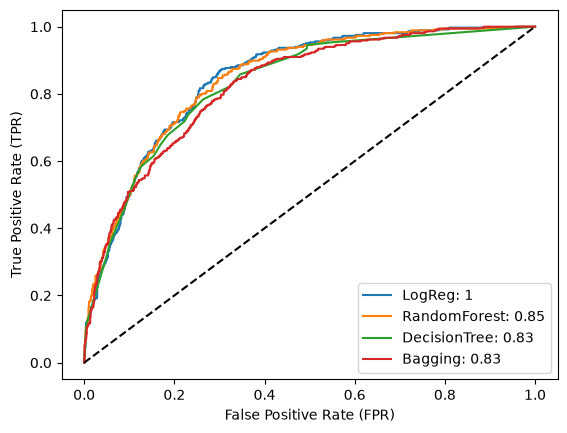

In [ ]:
# from sklearn.metrics import roc_curve
# import matplotlib.pyplot as plt


# # построение ROC-кривой
# logreg_fpr, logreg_tpr, _ = roc_curve(y_test, logreg_pred)
# decision_tree_fpr, decision_tree_tpr, _ = roc_curve(y_test, decision_tree_pred)
# random_forest_fpr, random_forest_tpr, _ = roc_curve(y_test, random_forest_pred)
# bagging_fpr, bagging_tpr, _ = roc_curve(y_test, bagging_pred)

# metrics = [
#     ["LogReg", logreg_auc_score, logreg_fpr, logreg_tpr],
#     ["DecisionTree", decision_tree_auc_score, decision_tree_fpr, decision_tree_tpr],
#     ["RandomForest", random_forest_auc_score, random_forest_fpr, random_forest_tpr],
#     ["Bagging", bagging_auc_score, bagging_fpr, bagging_tpr]
# ]

# metrics.sort(key=lambda x: x[1], reverse=True)

# plt.plot(metrics[0][2], metrics[0][3], label=f"{metrics[0][0]}: {metrics[0][1]}")
# plt.plot(metrics[1][2], metrics[1][3], label=f"{metrics[1][0]}: {metrics[1][1]}")
# plt.plot(metrics[2][2], metrics[2][3], label=f"{metrics[2][0]}: {metrics[2][1]}")
# plt.plot(metrics[3][2], metrics[3][3], label=f"{metrics[3][0]}: {metrics[3][1]}")

# plt.plot([0, 1], [0, 1], 'k--')

# plt.xlabel('False Positive Rate (FPR)')
# plt.ylabel('True Positive Rate (TPR)')
# plt.legend()
# plt.show()